# CNNs for Image Segmentation and Super-Resolution

In this lab we will learn two important **image-to-image tasks** in deep learning:

1. **Image Segmentation**
2. **Image Super-Resolution**

Unlike image classification (which outputs a single label), these tasks require the model to **predict an entire image as output**.

This means that the neural network produces **pixel-wise predictions**.

By the end of this demo you will understand:

- What **image segmentation** is
- What **image super-resolution** is
- How **CNN architectures** can solve these tasks
- How to evaluate segmentation using **Intersection over Union (IoU)**

# Part 1: What is Image Segmentation?

Image segmentation means **classifying every pixel in an image**.

Instead of predicting one label for the whole image, the model predicts a **label for each pixel**.

Example:

Input image → Model → Segmentation mask

A **segmentation mask** is an image where each pixel represents the class of the corresponding pixel in the original image.

Example classes:
- Background
- Person
- Car
- Road
- Animal

For simplicity in this lab we will do **binary segmentation**:

0 → Background  
1 → Object
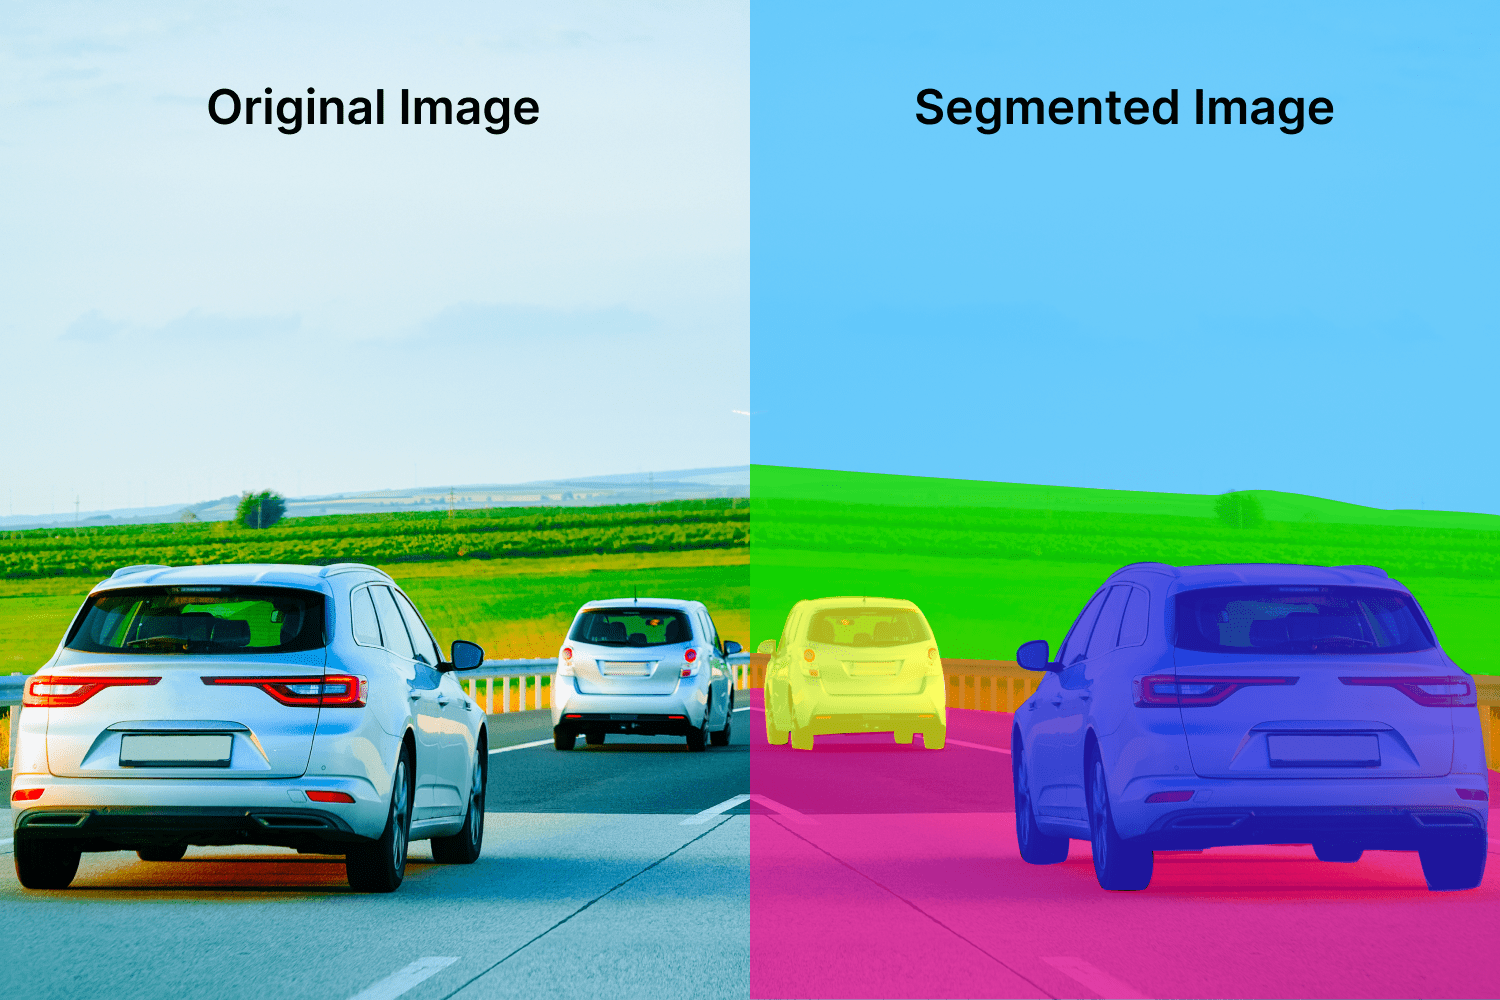

# CNN Architecture for Segmentation

Segmentation models often use an **encoder–decoder architecture**.

Encoder:
- Extracts features
- Reduces spatial size

Decoder:
- Upsamples features
- Produces pixel predictions

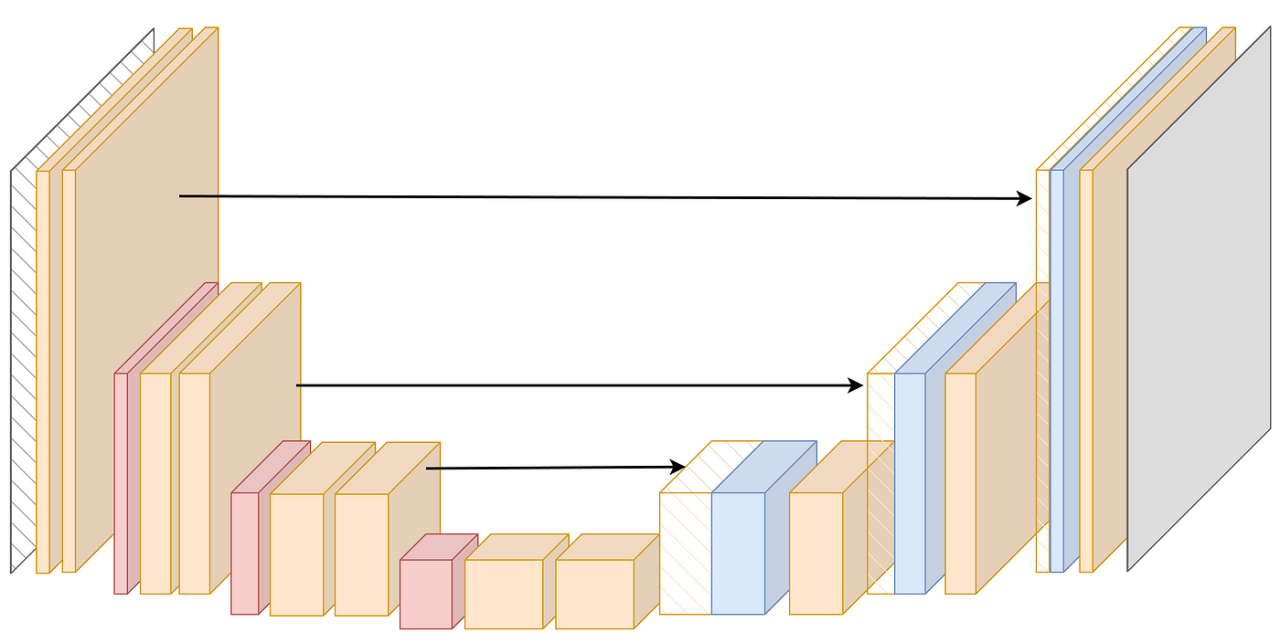

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

# Loading a Real Segmentation Dataset

We will use the **Oxford-IIIT Pet Dataset**, which contains:

- Images of cats and dogs
- Pixel-level segmentation masks

Each image has a corresponding mask where pixels represent:

- Background
- Pet
- Outline

For simplicity, we will convert this into a **binary segmentation problem**:

0 → Background  
1 → Pet

In [ ]:
from torchvision.datasets import OxfordIIITPet

image_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.PILToTensor()
])

dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

# Preparing Data for Training

The segmentation masks contain three values:

1 → Pet  
2 → Background  
3 → Outline

To simplify the task, we convert this to **binary segmentation**:

Pet → 1  
Everything else → 0

In [ ]:
images = []
masks = []

for i in range(200):  # small subset for quick training

    img, mask = dataset[i]

    mask = (mask == 1).float()   # pet vs background

    images.append(img)
    masks.append(mask)

images = torch.stack(images)
masks = torch.stack(masks)

print(images.shape, masks.shape)

torch.Size([200, 3, 128, 128]) torch.Size([200, 1, 128, 128])


# Visualizing the Dataset

Let us visualize:

- The input image
- The segmentation mask

The mask should highlight the **pet region**.

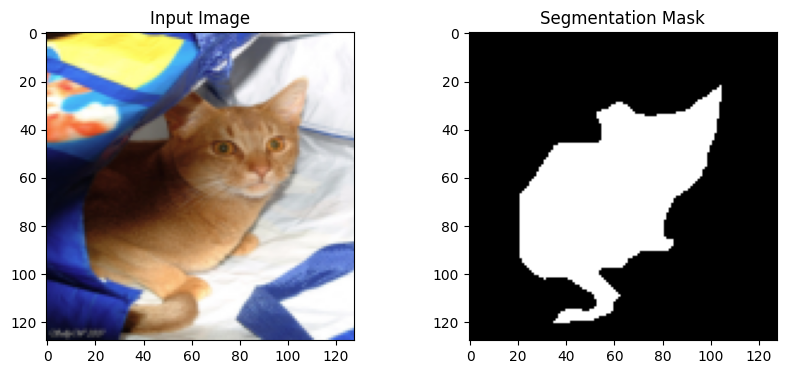

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(images[0].permute(1,2,0))

plt.subplot(1,2,2)
plt.title("Segmentation Mask")
plt.imshow(masks[0][0], cmap="gray")

plt.show()

# Building a Simple CNN for Image Segmentation

Now we will build a **Convolutional Neural Network (CNN)** that performs image segmentation.

Recall that **image segmentation means predicting a label for every pixel in the image**.

Unlike classification, where we predict a single label, segmentation produces a **pixel-wise output mask**.

Our model will follow a simple **Encoder–Decoder architecture**.

The architecture contains two main parts:

Encoder:
- Extracts hierarchical features
- Reduces spatial dimensions

Decoder:
- Upsamples the feature maps
- Predicts the segmentation mask

The final output is a **segmentation mask with pixel values between 0 and 1**.



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
class SimpleSegNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32,16,2,stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,2,stride=2),
            nn.Sigmoid()
        )

    def forward(self,x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

# Model Initialization

We now create the model and define the **loss function** and **optimizer**.

## Loss Function

We use **Binary Cross Entropy (BCE) Loss**.

Why?

Because this is a **binary segmentation problem**:

0 → Background  
1 → Pet

The loss measures how different the predicted mask is from the ground truth mask.

## Optimizer

We use the **Adam optimizer**, which is widely used for training deep neural networks.

In [ ]:
model = SimpleSegNet().to(device)

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
images = images.to(device)
masks = masks.to(device)

# Training the Segmentation Model

During training the network learns to predict segmentation masks.

Each training iteration consists of the following steps:

1. Pass input images through the model
2. Compute the loss between predicted mask and ground truth mask
3. Compute gradients using backpropagation
4. Update model parameters using the optimizer

In [ ]:
from tqdm import tqdm
loss=0
for epoch in tqdm(range(1000)):

    preds = model(images)

    loss = criterion(preds, masks)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("Loss: ", loss.item())

    # print("Epoch:", epoch, "Loss:", loss.item())

100%|██████████| 1000/1000 [01:22<00:00, 12.09it/s]


Loss:  0.38963237404823303


# Visualizing Segmentation Predictions

After training, we visualize the predictions.

We compare:

1. Input image
2. Ground truth mask
3. Predicted mask

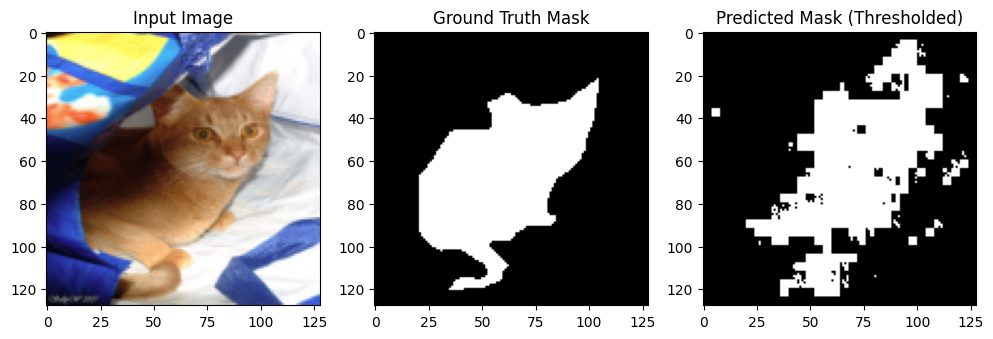

In [ ]:
pred = model(images[0:1]).detach().cpu()

# Apply threshold
pred_mask = (pred > 0.5).float()

img = images[0].cpu()
mask = masks[0].cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(mask[0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask (Thresholded)")
plt.imshow(pred_mask[0][0], cmap="gray")

plt.show()

# Evaluation Metric: Intersection over Union (IoU)

To evaluate segmentation models, we commonly use **Intersection over Union (IoU)**.

IoU measures how much the predicted segmentation overlaps with the true segmentation.

Formula:

IoU = Intersection / Union

### Intersection
Pixels where both:
- prediction = 1
- ground truth = 1

### Union
Pixels where:
- prediction = 1 OR ground truth = 1

### Interpretation

IoU = 0 → No overlap  
IoU = 1 → Perfect segmentation

In [ ]:
def compute_iou(pred, target):

    pred = pred > 0.5

    intersection = (pred & target.bool()).sum()
    union = (pred | target.bool()).sum()

    iou = intersection / union

    return iou.item()

iou = compute_iou(pred, masks[0:1].cpu())

print("IoU:", iou)

IoU: 0.5530316233634949


# Part 2: Image Super-Resolution

Now we move to the second task: **Image Super-Resolution**.

Image super-resolution refers to the task of **reconstructing a high-resolution image from a low-resolution image**.

Pipeline:

Low Resolution Image  
↓  
CNN Model  
↓  
High Resolution Image

The model learns to **recover missing details such as edges and textures**.

# Creating Low-Resolution Images

To train a super-resolution model we need:

Input → Low-resolution image  
Target → High-resolution image

We simulate low-resolution images by **downsampling and then upsampling the original image**.

In [ ]:
hr_images = images

lr_images = nn.functional.interpolate(hr_images, scale_factor=0.5)
lr_images = nn.functional.interpolate(lr_images, scale_factor=2)

# Visualizing Low vs High Resolution Images

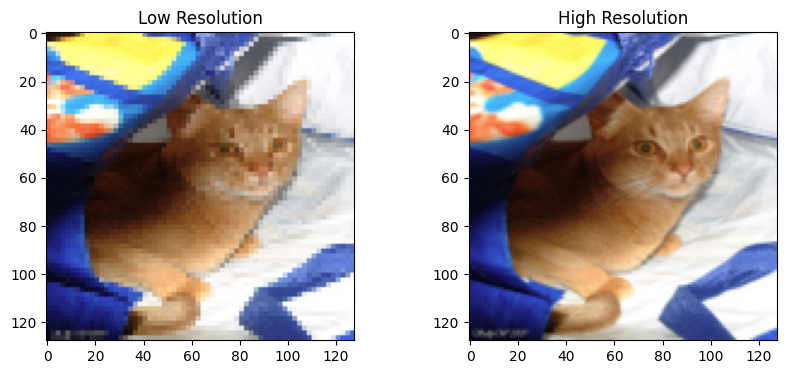

In [ ]:
lr_img = lr_images[0].cpu()
hr_img = hr_images[0].cpu()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Low Resolution")
plt.imshow(lr_img.permute(1,2,0))

plt.subplot(1,2,2)
plt.title("High Resolution")
plt.imshow(hr_img.permute(1,2,0))

plt.show()

# Super-Resolution CNN Model

We now build a CNN that learns the mapping:

Low Resolution Image → High Resolution Image

The model extracts features from the low-resolution image and reconstructs a higher-quality image.

This model is a simplified version of the original SRCNN introduced in 2014.


In [ ]:
class SrCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3,64,9,padding=4),
            nn.ReLU(),
            nn.Conv2d(64,32,5,padding=2),
            nn.ReLU(),
            nn.Conv2d(32,3,5,padding=2)
        )

    def forward(self,x):
        return self.net(x)

# Training Setup

For super-resolution we use **Mean Squared Error (MSE)**.

This loss measures the difference between:

Predicted high-resolution image  
Ground truth high-resolution image

In [ ]:
sr_model = SrCNN().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(sr_model.parameters(), lr=0.001)

lr_images = lr_images.to(device)
hr_images = hr_images.to(device)

In [ ]:
loss=0
for epoch in tqdm(range(100)):

    preds = sr_model(lr_images)

    loss = criterion(preds, hr_images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Loss:", loss.item())

100%|██████████| 100/100 [00:56<00:00,  1.78it/s]


Loss: 0.002551859011873603


# Visualizing Super-Resolution Results

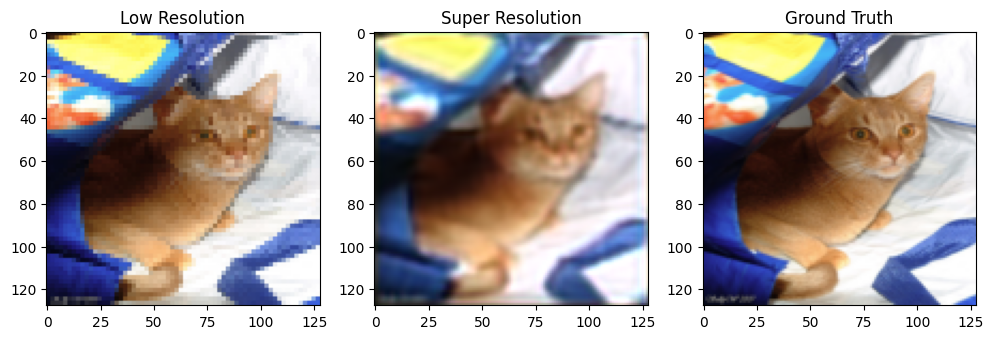

In [ ]:
sr_pred = sr_model(lr_images[0:1]).detach().cpu()

lr_img = lr_images[0].cpu()
hr_img = hr_images[0].cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Low Resolution")
plt.imshow(lr_img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Super Resolution")
plt.imshow(sr_pred[0].permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(hr_img.permute(1,2,0))

plt.show()